# Summary: Learning Deep Architectures for AI (Yoshua Bengio, 2009)

# https://www.iro.umontreal.ca/~lisa/pointeurs/TR1312.pdf

## Abstract
This paper presents a theoretical and algorithmic case for deep architectures—models composed of multiple layers of non-linear operations—as necessary for approaching AI-level tasks such as vision and language understanding. The author reviews computational complexity results showing that insufficiently deep architectures can require exponentially more computational elements than deep ones to represent the same function, and surveys learning algorithms (notably Restricted Boltzmann Machines and Deep Belief Networks) that made training deep models tractable for the first time.

## Problems
- **Depth limitation**: Most machine learning algorithms (kernel machines, one-hidden-layer neural networks, boosting) are shallow (depth 1–3), which theoretical results show can require exponentially many computational elements to represent functions that a deeper architecture represents compactly.
- **Locality of estimators**: Many non-parametric algorithms (kernel machines with local kernels, decision trees, manifold learning methods) generalize only locally, requiring training examples proportional to the number of "variations" in the target function—an approach ill-suited to highly-varying functions needed for AI.
- **Optimization difficulty**: Deep neural networks trained by standard gradient-based methods from random initialization tend to get stuck in poor local minima or plateaus, with worse generalization than shallow (1–2 hidden layer) networks.

## Proposed Solutions
- **Distributed representations**: Encoding input via many non-mutually-exclusive features (a "multi-clustering") rather than local/one-hot representations, enabling exponentially more compact and expressive representations of configurations.
- **Greedy layer-wise unsupervised pre-training**: Train each layer as an unsupervised model (autoassociator or Restricted Boltzmann Machine, RBM) on the representation produced by the previous layer, then stack these layers to initialize a deep network (Deep Belief Network, DBN), followed by supervised fine-tuning.
- **Contrastive Divergence (CD)**: An approximate, tractable estimator of the log-likelihood gradient for RBMs, replacing an intractable full MCMC-based estimator with a short (often $$k=1$$) Gibbs chain starting from the observed data.
- **Continuation methods framing**: Interpreting greedy layer-wise training, temperature/regularization scheduling, and curriculum learning as instances of continuation optimization, which gradually transforms an easy (smooth/convex) problem into the difficult target problem.

## Purpose
To provide theoretical motivation (via circuit complexity and locality-of-estimator arguments) for why deep, distributed-representation architectures are required for AI-level tasks, and to explain the principles behind newly successful algorithms (RBMs, DBNs, stacked autoassociators, convolutional networks) that make deep architectures trainable, while identifying open research questions for the field.

## Methodology
- **Theoretical analysis**: Uses results from boolean/threshold circuit complexity theory (e.g., Håstad's theorem on depth-$$k-1$$ circuits requiring exponential size to replicate depth-$$k$$ functions) and kernel machine theory (Gaussian kernel bump-counting theorems, parity function analysis) to formalize the limitations of shallow and local architectures.
- **Energy-based model formulation**: Defines probability via
$$P(x) = \frac{e^{-\text{Energy}(x)}}{Z}, \quad Z = \sum_x e^{-\text{Energy}(x)}$$
and derives the RBM as a bilinear-energy special case:
$$\text{Energy}(x,h) = -b'x - c'h - h'Wx$$
with tractable factorized conditionals $$P(h|x) = \prod_i P(h_i|x)$$ and $$P(x|h) = \prod_j P(x_j|h)$$.
- **Contrastive Divergence derivation**: Shows CD-$$k$$ arises from truncating an infinite series expansion of the log-likelihood gradient along a Gibbs chain (Theorem 7.3, Corollary 7.4), linking it to reconstruction error as a biased, low-variance approximation.
- **Algorithmic description**: Provides pseudocode (Algorithm 1: RBMupdate via CD; Algorithm 2: greedy unsupervised DBN training) detailing per-layer Gibbs sampling and parameter updates.
- **Variational justification**: Uses a Jensen's-inequality-based lower bound decomposition,
$$\log P(x) = KL(Q(h|x)\|P(h|x)) + H_{Q(h|x)} + \sum_h Q(h|x)(\log P(h) + \log P(x|h))$$
to justify why greedy layer-wise RBM stacking provably improves (a lower bound on) the DBN log-likelihood.
- **Survey of related architectures**: Discusses convolutional neural networks, autoassociators, Boltzmann machines, conditional/temporal RBMs, factored RBMs, and stacked autoassociators as complementary or alternative deep learning building blocks.

## Results
- Formal theorems demonstrate that depth-$$k-1$$ monotone weighted threshold circuits require size at least $$2^{cN}$$ to represent certain functions compactly representable at depth $$k$$.
- Gaussian kernel machines are shown to require at least $$k$$ training examples for functions with $$2k$$ sign changes, and at least $$2^{d-1}$$ non-zero coefficients to solve $$d$$-bit parity—illustrating exponential inefficiency of local estimators on highly-varying functions.
- Decision trees are proven to require at least $$N$$ training examples proportional to the number of piecewise-constant regions needed, and at least $$2^d(1-2\epsilon)$$ examples for $$d$$-bit parity.
- Empirical evidence (cited from Bengio et al., 2007) shows that gradient-based training of deep supervised networks from random initialization gets stuck in poor local minima, particularly affecting lower layers, while networks initialized via greedy unsupervised layer-wise pre-training (RBMs/autoassociators) achieve markedly better generalization.
- Convolutional neural networks are highlighted as a notable exception that trains well despite depth (5–7 layers), attributed to small fan-in and strong architectural priors.
- CD-1 is shown empirically to give good practical results despite being a heavily truncated/biased gradient estimator.

## Conclusions
The paper concludes that theoretical limitations of shallow and local architectures motivate the pursuit of deep, distributed representations for AI-level learning tasks. Restricted Boltzmann Machines and their stacked form, Deep Belief Networks, trained via Contrastive Divergence and greedy layer-wise unsupervised pre-training, represent a successful practical strategy for optimizing deep architectures that standard gradient descent alone cannot reliably train. This layer-wise strategy is reframed as a specific instance of continuation optimization methods, connecting it conceptually to curriculum learning and regularization-path tracking. The paper closes by enumerating 24 open research questions spanning theory (depth requirements, complexity generalizations), optimization (local minima in RBMs, joint multi-layer training), architecture design (sparsity, non-parametric energy functions, structured/variable-size data), and broader learning paradigms (semi-supervised learning, curriculum design, biological plausibility).

# Mathematical and Statistical Content: Learning Deep Architectures for AI

## 1. Depth and Function Composition

**Linear threshold unit (artificial neuron):**
$$f(x) = \mathbb{1}_{w'x + b \geq 0} \tag{1}$$
A neuron fires (outputs 1) if a weighted sum of inputs plus a bias exceeds zero. This is the basic computational element used to define "depth" — the longest path from input to output in a computation graph.

**Role:** Depth of an architecture equals the number of layers of composed operations. The paper uses this to formally compare shallow vs. deep models.

## 2. Circuit Complexity Theorems (Why Depth Matters)

**Theorem 2.1 (Håstad & Goldmann, 1991):** A monotone weighted threshold circuit of depth $$k-1$$ computing a function in a specific function class $$\mathcal{F}_{k,N}$$ needs size at least
$$2^{cN}$$
for constant $$c>0$$.

**Meaning:** Reducing depth by just one level can force an exponential blow-up in the number of computational units needed. This is the central theoretical argument for why deep architectures can be exponentially more efficient than shallow ones.

**Polynomial example (compactness argument):**
$$\prod_{i=1}^n \sum_{j=1}^m a_{ij} x_j$$
can be computed with $$O(mn)$$ elements as a product-of-sums, but needs $$O(n^m)$$ elements if forced into a sum-of-products (depth-2) form — illustrating how reorganizing composition depth changes representational efficiency dramatically.

## 3. Kernel Machines and Locality

**General kernel machine (predictor):**
$$f(x) = b + \sum_i \alpha_i K(x, x_i) \tag{2}$$
Output is a bias plus a weighted sum of "similarity" scores between the input $$x$$ and stored training examples $$x_i$$ (prototypes), weighted by learned coefficients $$\alpha_i$$.

**Gaussian (local) kernel:**
$$K(x,x_i) = e^{-\|x-x_i\|^2/\sigma^2} = \prod_i e^{-(u_i-v_i)^2/\sigma^2}$$
Measures closeness; large only when $$x$$ is near $$x_i$$ (within a region controlled by $$\sigma$$). This is why such models are "local estimators" — they only generalize well near training points.

**Theorem 3.1 (bumps theorem):** If the target decision function must change sign $$2k$$ times along a line, a Gaussian kernel machine needs at least $$k$$ non-zero coefficients (hence $$k$$ training examples).

**Meaning:** The number of required training examples scales with the number of "wiggles" (variations) in the function — highly oscillating functions are expensive to learn locally, even if they have a simple underlying structure.

**Theorem 3.2 (parity problem):**
$$f(x) = b + \sum_{i=1}^{2^d} \alpha_i K_\sigma(x_i, x)$$
solving $$d$$-bit parity requires at least $$2^{d-1}$$ non-zero coefficients.

**Meaning:** For parity (output flips with any single bit change), local kernel methods need exponentially many examples in the input dimension $$d$$ — a worst-case illustration of the curse of dimensionality for local estimators.

## 4. Decision Trees

**Proposition 3.3:** If $$N$$ constant pieces are needed to approximate a target function within error $$\epsilon$$, a decision tree needs at least $$N$$ training examples to achieve that error.

**Theorem 3.4:** For $$d$$-bit parity, a decision tree needs at least
$$2^d(1-2\epsilon)$$
examples to reach generalization error $$\leq \epsilon$$.

**Meaning:** Like kernel machines, decision trees are local estimators — they partition input space and need enough examples per region; parity again demonstrates worst-case exponential data requirements.

## 5. Distributed Representations

Local representation of an integer $$i \in \{1,\ldots,N\}$$: one-hot vector of $$N$$ bits.
Distributed representation: vector of $$\log_2 N$$ bits.

**Meaning:** A distributed code can represent the same number of configurations exponentially more compactly than a local (one-hot) code, motivating representations where many features can be active/inactive independently (multi-clustering) rather than mutually exclusive clusters.

## 6. Multi-Layer Neural Networks

**Forward computation:**
$$z_\ell = \tanh(b_\ell + W_\ell z_{\ell-1}) \tag{3}$$
Each layer's output is a non-linear (tanh) transformation of a linear combination of the previous layer's output.

**Softmax output layer:**
$$z_{Li} = \frac{e^{b_{Li}+W_{Li}z_{L-1}}}{\sum_j e^{b_{Lj}+W_{Lj}z_{L-1}}} \tag{4}$$
Converts final layer activations into a probability distribution over classes, used for multi-class classification; interpreted as $$P(Y=i|x)$$.

## 7. Energy-Based Models

**Boltzmann-style probability distribution:**
$$P(x) = \frac{e^{-\text{Energy}(x)}}{Z}, \qquad Z = \sum_x e^{-\text{Energy}(x)} \tag{7,8}$$
Assigns high probability to low-energy (plausible) configurations; $$Z$$ (the partition function) normalizes the distribution but is generally intractable to compute exactly.

**Products of experts:**
$$\text{Energy}(x) = \sum_i f_i(x), \qquad P(x) \propto \prod_i e^{-f_i(x)} \tag{9,10}$$
Combines multiple "expert" constraints multiplicatively; each expert penalizes implausible configurations, and their product forms a distributed representation of constraint satisfaction.

**Hidden variables / marginalization:**
$$P(x,h) = \frac{e^{-\text{Energy}(x,h)}}{Z}, \qquad P(x) = \sum_h \frac{e^{-\text{Energy}(x,h)}}{Z} \tag{11,12}$$

**Free energy (summarizes hidden variables):**
$$\text{FreeEnergy}(x) = -\log \sum_h e^{-\text{Energy}(x,h)} \tag{14}$$
Reduces a model with hidden units to an equivalent visible-only energy function, enabling
$$P(x) = \frac{e^{-\text{FreeEnergy}(x)}}{\sum_x e^{-\text{FreeEnergy}(x)}} \tag{13}$$

**Log-likelihood gradient (general form):**
$$\frac{\partial \log P(x)}{\partial \theta} = -\frac{\partial \text{FreeEnergy}(x)}{\partial \theta} + \sum_{\tilde{x}} P(\tilde{x})\frac{\partial \text{FreeEnergy}(\tilde{x})}{\partial \theta} \tag{15}$$
and its expectation over data:
$$E_{\hat{P}}\left[\frac{\partial \log P(x)}{\partial \theta}\right] = -E_{\hat{P}}\left[\frac{\partial \text{FreeEnergy}(x)}{\partial\theta}\right] + E_P\left[\frac{\partial\text{FreeEnergy}(x)}{\partial\theta}\right] \tag{16}$$

**Meaning:** Training moves parameters to lower the energy (raise probability) of real data (the $$\hat{P}$$ term) while raising the energy of samples generated by the current model (the $$P$$ term) — this is the "positive phase / negative phase" contrast at the heart of Boltzmann-machine-style learning.

**Tractable case (sum over hidden units factorizes):**
When
$$\text{Energy}(x,h) = -\beta(x) + \sum_i \gamma_i(x,h_i) \tag{17}$$
the free energy simplifies to a closed form:
$$\text{FreeEnergy}(x) = -\beta(x) - \sum_i \log\sum_{h_i} e^{-\gamma_i(x,h_i)} \tag{19}$$

**Conditional energy-based model:**
$$P(y|x) = \frac{e^{-\text{Energy}(x,y)}}{\sum_y e^{-\text{Energy}(x,y)}} \tag{20}$$
Used when only a decision variable $$y$$ (not the full joint) needs to be predicted, avoiding the need to normalize over all $$x$$.

## 8. Boltzmann Machines

**General (fully-connected) energy function:**
$$\text{Energy}(x,h) = -b'x - c'h - h'Wx - x'Ux - h'Vh \tag{21}$$
Includes interaction terms between visible-visible ($$U$$), hidden-hidden ($$V$$), and visible-hidden ($$W$$) units.

**Gradient via Gibbs sampling:**
$$\frac{\partial\log P(x)}{\partial\theta} = -\sum_h P(h|x)\frac{\partial \text{Energy}(x,h)}{\partial\theta} + \sum_{x,h}P(x,h)\frac{\partial\text{Energy}(x,h)}{\partial\theta} \tag{22}$$

**Gibbs sampling update rule:**
$$X_i \sim P(X_i | X_{-i}=x_{-i}) \tag{23}$$
Each variable is resampled conditioned on all others; repeated sweeps converge to the joint distribution.

**Single-unit conditional (sigmoid form):**
$$P(y_i=1|y_{-i}) = \text{sigm}(d_i + A_i'y_{-i}) \tag{25}$$
Shows that Boltzmann machine unit updates reduce to the familiar sigmoid neuron equation.

**Meaning:** Full Boltzmann machines are expensive because sampling requires two nested Markov chains (positive and negative phase) with as many sub-steps as units — motivating the restricted version below.

## 9. Restricted Boltzmann Machines (RBM)

**Bilinear energy (no within-layer connections, $$U=V=0$$):**
$$\text{Energy}(x,h) = -b'x - c'h - h'Wx \tag{26}$$

**Free energy (tractable):**
$$\text{FreeEnergy}(x) = -b'x - \sum_i \log \sum_{h_i} e^{h_i W_i x} \tag{27}$$

**Factorized conditionals:**
$$P(h|x) = \prod_i P(h_i|x), \qquad P(h_i=1|x) = \text{sigm}(c_i + W_i x) \tag{28}$$
$$P(x|h) = \prod_j P(x_j|h), \qquad P(x_j=1|h) = \text{sigm}(b_j + W'_{.j}\cdot h) \tag{30}$$

**Meaning:** Because visible and hidden units only interact pairwise (not within a layer), both conditional distributions factorize into independent sigmoid neurons — this is what makes RBMs efficient to sample from and train, unlike general Boltzmann machines.

**Mixture interpretation:**
$$P(x) = \sum_h P(x|h)P(h) \tag{31}$$
An RBM can be seen as a Gaussian (or other) mixture with $$2^n$$ components (for $$n$$ hidden bits), but the components share parameters, so they aren't independently tunable.

**Gibbs sampling chain in RBMs (alternating updates):**
$$x_0 \sim \hat{P}(x),\ h_0\sim P(h|x_0),\ x_1 \sim P(x|h_0),\ h_1\sim P(h|x_1), \ldots \tag{32}$$
Because the two conditionals factorize, sampling alternates efficiently between the full hidden layer and full visible layer.

## 10. Contrastive Divergence (CD)

**CD-$$k$$ parameter update:**
$$\Delta\theta = -\frac{\partial \text{FreeEnergy}(x)}{\partial\theta} + \frac{\partial \text{FreeEnergy}(\tilde{x})}{\partial\theta} \tag{33}$$
where $$\tilde{x}$$ is the state of the visible units after $$k$$ steps of Gibbs sampling starting from a real training example $$x$$.

**Meaning:** This approximates the true (intractable) gradient by comparing a real data point against a "corrupted" reconstruction obtained after a short Markov chain — a practical shortcut for training RBMs. Even $$k=1$$ (CD-1) works well empirically.

**Lemma 7.1 (log-likelihood expansion along the Gibbs chain):**
$$\log P(x_1) = \log P(x_t) + \sum_{s=1}^{t-1}\log\frac{P(x_s|h_s)}{P(h_s|x_s)} + \log\frac{P(h_s|x_{s+1})}{P(x_{s+1}|h_s)} \tag{39}$$

**Lemma 7.2:** For any model,
$$E\left[\frac{\partial \log P(Y)}{\partial \theta}\right] = 0 \tag{41}$$
(a standard identity: the expected score function is zero under the model's own distribution.)

**Theorem 7.3 (gradient series expansion):**
$$\frac{\partial\log P(x_1)}{\partial\theta} = \sum_{s=1}^{t-1}\left(E\left[\frac{\partial\log P(x_s|h_s)}{\partial\theta}\right] + E\left[\frac{\partial\log P(h_s|x_{s+1})}{\partial\theta}\right]\right) + E\left[\frac{\partial\log P(x_t)}{\partial\theta}\right] \tag{42}$$
with terms shrinking to zero as $$s,t\to\infty$$.

**Corollary 7.4:** Truncating this series to the first $$k$$ terms and replacing expectations with samples exactly recovers the CD-$$k$$ update for binomial RBMs.

**Meaning:** These results formally justify Contrastive Divergence — it is not an ad hoc heuristic but a truncated, biased estimator of an exact (infinite) series expansion of the true log-likelihood gradient. Truncating early trades bias for computational tractability.

**Reconstruction error connection:**
$$-\log P(x_1|\hat{h}_1) \tag{45}$$
Taking just the first term of the expansion (with a mean-field approximation $$\hat{h}_1 = E[h_1|x_1]$$) gives exactly the negative of the gradient of reconstruction error — the standard criterion used to train autoassociators. This links RBM training (CD) and autoencoder training (reconstruction error) as different truncations of the same underlying gradient expansion.

## 11. Generalized RBMs

**Proposition 8.1:** Any energy function whose conditionals factorize as $$P(h|x)=\prod_i P(h_i|x)$$ and $$P(x|h)=\prod_j P(x_j|h)$$ must have the form
$$\text{Energy}(x,h) = \sum_j \phi_j(x_j) + \sum_i \xi_i(h_i) + \sum_{i,j}\eta_{i,j}(h_i,x_j) \tag{46}$$
This generalizes the RBM beyond binary units to arbitrary (e.g., continuous, exponential-family) unit types while preserving tractable sampling.

**Proposition 8.2 (generalized CD-$$k$$):** For this general energy form, the CD-$$k$$ gradient estimate depends only on the first pair $$(x_1,h_1)$$ and last pair $$(x_k,h_k)$$ in the Gibbs chain — all intermediate terms cancel:
$$\Delta\theta = \sum_{i,j}\frac{\partial\eta_{i,j}(h_{1,i},x_{1,j})}{\partial\theta} - \sum_{i,j}\frac{\partial\eta_{i,j}(h_{k,i},x_{k,j})}{\partial\theta} \tag{50}$$

**Meaning:** This shows Contrastive Divergence generalizes cleanly beyond binary RBMs to a broad family of factorized energy-based models.

## 12. Deep Belief Networks (DBN)

**Joint distribution over $$\ell$$ layers:**
$$P(x, h^1,\ldots,h^\ell) = \left(\prod_{k=1}^{\ell-2}P(h^k|h^{k+1})\right)P(h^{\ell-1},h^\ell) \tag{51}$$
The bottom layers form a directed sigmoid belief network, while the top two layers form an undirected RBM — a hybrid graphical model.

**Variational lower bound (via Jensen's inequality):**
$$\log P(x) = H_{Q(h|x)} + \sum_h Q(h|x)\big(\log P(h) + \log P(x|h)\big) \tag{52}$$

**Exact decomposition (including the KL gap):**
$$\log P(x) = KL(Q(h|x)\|P(h|x)) + H_{Q(h|x)} + \sum_h Q(h|x)\big(\log P(h)+\log P(x|h)\big) \tag{53}$$

**Meaning:** Equation (52) is a lower bound on the true log-likelihood; equation (53) reveals that the gap between the bound and the true value is exactly a KL divergence between an approximate posterior $$Q$$ (from a single-layer RBM) and the true DBN posterior $$P$$. This underlies the proof that greedily adding and training another RBM layer (to improve the term $$\sum_h Q(h|x)\log P(h)$$) provably increases (a lower bound on) the overall model likelihood — the theoretical justification for greedy layer-wise training.

**Ideal target distribution for a newly added layer:**
$$P^*(h^1) = \sum_x \hat{P}(x) Q(h^1|x) \tag{55}$$
The best possible marginal for the next layer is the empirical data distribution pushed through the first-layer RBM's mapping.

## 13. Wake-Sleep Algorithm

**Wake phase update (fits generative weights to inferred hidden activations):**
$$\sum_{h^1,\ldots,h^{\ell-1}} Q(h^{\ell-1}|h^{\ell-2})\cdots Q(h^1|x)\prod_{k=1}^{\ell-1}\frac{\partial \log P(h^{k-1}|h^k)}{\partial\theta} \tag{60}$$

**Sleep phase update (fits recognition weights to model-generated samples):**
$$\sum_{h^0,\ldots,h^{\ell-1}} P(h^{\ell-1})P(h^{\ell-2}|h^{\ell-1})\cdots P(h^0|h^1)\prod_{k=1}^{\ell-1}\frac{\partial\log Q(h^k|h^{k-1})}{\partial\theta} \tag{61}$$

**Meaning:** These alternate between updating generative parameters using data-driven (inferred) hidden states ("wake") and updating recognition parameters using model-generated fantasy samples ("sleep"), approximating the otherwise intractable joint optimization of both directions in a DBN.

## 14. Continuation / Regularization-Path Optimization

**Regularized RBM training objective:**
$$C_\lambda(\theta) = -\sum_i \log P_\theta(x_i) - \|\theta\|^2\log\lambda \tag{63}$$

**Meaning:** As $$\lambda \to 0$$, parameters shrink toward zero and the objective becomes convex (easy to optimize); as $$\lambda\to 1$$, regularization vanishes and the true (harder) objective is recovered. Gradually increasing $$\lambda$$ while tracking local optima is a "continuation method" — used to argue why small-weight initialization plus stochastic gradient descent (which naturally increases weight magnitude over training, similar to early stopping's implicit regularization) tends to find better solutions than optimizing the unregularized objective directly from the start.

## Summary of Statistical Themes

| Concept | Statistical Role in the Paper |
|---|---|
| Circuit complexity theorems | Prove exponential separation between shallow and deep representational efficiency |
| Kernel/tree sample-complexity theorems | Prove local estimators need training-set size proportional to function "variation count" |
| Energy-based probability | Defines an unnormalized-score-to-probability mapping used throughout RBMs/DBNs |
| Free energy | Marginalizes out hidden variables to make gradients tractable |
| Contrastive Divergence | Biased but tractable Monte Carlo estimator of an intractable likelihood gradient |
| Gibbs sampling | MCMC method used to approximately sample from Boltzmann-machine-family models |
| Variational (Jensen) bound / KL divergence | Justifies greedy layer-wise training as monotonically improving a likelihood lower bound |
| Wake-sleep algorithm | Approximate EM-like alternating optimization for directed deep generative models |

# Problems, Limitations, and Proposed Solutions in *Learning Deep Architectures for AI*

| # | Key Problem / Research Gap | Limitation of Prior Work | Proposed Solution in the Paper |
|---|---|---|---|
| 1 | Most learning algorithms use shallow architectures (depth 1–3): linear/logistic regression, kernel machines, one-hidden-layer neural nets, boosting, decision trees. | Theoretical results (e.g., Håstad & Goldmann, 1991) show that functions compactly representable at depth $$k$$ may require exponentially more computational elements at depth $$k-1$$, causing poor statistical efficiency (more elements to tune means more training examples needed). | Motivates the use of deep architectures (multiple layers of non-linear transformation) that can represent highly-varying functions compactly, reducing the number of examples needed for good generalization. |
| 2 | Many non-parametric algorithms (Gaussian kernel machines, decision trees, manifold learning methods) are "local estimators." | Local estimators require a number of training examples proportional to the number of variations ("bumps") in the target function; provably need exponentially many examples for highly-varying functions such as parity (Theorems 3.1, 3.2, 3.4). | Proposes distributed, non-local representations, where hidden units jointly encode inputs via many partially-shared configurations, allowing generalization to unseen regions without needing one example per region. |
| 3 | Local/one-hot representations scale poorly with the number of concepts to be represented. | A one-hot code for $$N$$ categories needs $$N$$ bits, and clustering-based representations involve mutually exclusive, non-composable regions. | Introduces distributed ("multi-clustering") representations, where the input is not restricted to one active state but described by a factored code of size $$O(\log N)$$, exponentially more compact and compositional. |
| 4 | Deep neural networks trained with standard gradient-based methods from random initialization are hard to optimize. | Empirical evidence shows training gets stuck in poor local minima or plateaus, especially in lower layers, yielding worse generalization than shallow (1–2 hidden layer) networks. | Proposes greedy, layer-wise unsupervised pre-training (via autoassociators or RBMs) to initialize each layer before supervised fine-tuning, placing parameters in a favorable region of the optimization landscape. |
| 5 | Boltzmann machines require expensive, slow MCMC sampling (two nested Gibbs chains per example) for gradient estimation. | The full Boltzmann machine's intractable partition function and lack of factorized conditionals make training computationally prohibitive, historically causing it to be abandoned in favor of backpropagation. | Introduces the Restricted Boltzmann Machine (RBM), which removes intra-layer connections so that $$P(h\mid x)$$ and $$P(x\mid h)$$ factorize, enabling efficient alternating Gibbs sampling. |
| 6 | Computing the exact log-likelihood gradient for RBMs requires summing over an intractable partition function / running long MCMC chains to convergence. | Long Markov chains needed for unbiased gradient estimates make maximum-likelihood training of energy-based models computationally infeasible at scale. | Proposes Contrastive Divergence (CD-$$k$$), a biased but tractable gradient approximation using only $$k$$ steps of Gibbs sampling starting from the observed data, formally justified as a truncation of an infinite gradient series (Theorem 7.3). |
| 7 | No formal justification existed for why greedy, layer-wise stacking of RBMs into Deep Belief Networks (DBNs) should improve overall model performance. | Prior deep training heuristics lacked theoretical grounding, making it unclear whether such greedy procedures reliably improve, rather than degrade, likelihood. | Provides a variational (Jensen's inequality-based) proof that training each additional RBM layer improves a lower bound on the DBN's log-likelihood (Sections 11.1–11.2), justifying the greedy layer-wise algorithm. |
| 8 | Existing definitions of RBMs and CD were largely restricted to binary units. | Limits applicability to continuous-valued or other exponential-family data domains common in real-world tasks. | Generalizes the RBM energy function (Proposition 8.1) and CD update rule (Proposition 8.2) to any factorized energy form, extending applicability beyond binary units. |
| 9 | No unifying optimization framework explained why techniques like layer-wise pre-training, small-weight initialization, or curriculum-based training aid convergence. | Ad hoc use of such heuristics lacked a principled explanation of *why* they help avoid poor local minima. | Frames these as instances of continuation methods (gradually solving harder versions of a smoothed optimization problem), unifying layer-wise training, regularization-path/temperature scheduling, and curriculum learning under one theoretical lens. |
| 10 | Deep architectures other than DBNs (e.g., decision tree ensembles, kernel-learning methods) remain underexplored as "deep" models. | Research on deep architectures has focused almost exclusively on neural-network-style models, leaving open whether depth benefits extend to other model families. | Identifies this as an open research direction (Section 13.1, Open Questions), encouraging extension of the deep/distributed-representation paradigm beyond neural networks. |

In [1]:
# ============================================================
# EDUCATIONAL REPLICATION: "Learning Deep Architectures for AI" (Bengio, 2009)
# Core idea reproduced here: GREEDY LAYER-WISE UNSUPERVISED PRE-TRAINING
# of a Stacked Autoassociator (stacked autoencoder), followed by
# SUPERVISED FINE-TUNING of the full deep network (Section 9 of the paper).
#
# Pipeline:
#   1) Load CIFAR-10 from HuggingFace
#   2) Wrap in custom PyTorch Dataset
#   3) Build a 3-layer Stacked Autoencoder (mimics stacking RBMs/autoassociators)
#   4) Greedily pre-train each autoencoder layer (unsupervised reconstruction)
#   5) Stack encoders + classification head -> fine-tune supervised (5 epochs)
#   6) Evaluate, visualize, and build a publication-style dashboard
# ============================================================

# -----------------------------
# 0. IMPORTS
# -----------------------------
import io
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
import torchvision.transforms as T
from datasets import load_dataset
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from PIL import Image
from IPython.display import display, Image as IPImage

In [2]:
# -----------------------------
# 1. GLOBAL CONFIG
# -----------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(42)
np.random.seed(42)

IMG_SIZE = 64
BATCH_SIZE = 64
NUM_CLASSES = 10
FINE_TUNE_EPOCHS = 5      # Requirement: train for 5 epochs only (supervised fine-tuning)
PRETRAIN_EPOCHS = 3       # Small number of epochs per greedy AE layer (kept simple/fast)

# Exact class name -> label mapping required for CIFAR-10
CLASS_NAMES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

In [3]:
# -----------------------------
# 2. DATASET LOADING (HuggingFace CIFAR-10 — MANDATORY SOURCE)
# -----------------------------
# Load the CIFAR-10 dataset directly from the HuggingFace Hub.
ds = load_dataset("uoft-cs/cifar10")

# Define the transform pipelines exactly as required.
train_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

test_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


class HFCIFAR10Dataset(Dataset):
    """
    Custom PyTorch Dataset that wraps a HuggingFace CIFAR-10 split.
    - Reads the "img" field as a PIL Image.
    - Converts to RGB (safety check).
    - Applies the provided torchvision transform pipeline.
    - Returns (image_tensor, label) using the "label" field.
    """
    def __init__(self, hf_split, transform):
        self.hf_split = hf_split
        self.transform = transform

    def __len__(self):
        return len(self.hf_split)

    def __getitem__(self, idx):
        sample = self.hf_split[idx]
        img = sample["img"]
        if not isinstance(img, Image.Image):
            img = Image.fromarray(np.array(img))
        img = img.convert("RGB")
        img = self.transform(img)
        label = int(sample["label"])
        return img, label


# Wrap the HuggingFace train/test splits.
train_dataset_full = HFCIFAR10Dataset(ds["train"], train_transform)
test_dataset_full = HFCIFAR10Dataset(ds["test"], test_transform)

# Subset to keep the educational example fast and lightweight.
train_dataset = Subset(train_dataset_full, list(range(2000)))
test_dataset = Subset(test_dataset_full, list(range(400)))

# Wrap in DataLoaders.
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# -----------------------------
# 2b. SANITY CHECK
# -----------------------------
sample_batch_imgs, sample_batch_labels = next(iter(train_loader))
print("===== SANITY CHECK =====")
print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of test samples:     {len(test_dataset)}")
print(f"Shape of one batch of images: {sample_batch_imgs.shape}")
print(f"Label range: [{sample_batch_labels.min().item()}, {sample_batch_labels.max().item()}]")
print("First 8 class names in this batch:",
      [CLASS_NAMES[l.item()] for l in sample_batch_labels[:8]])
print("=========================\n")

README.md:   0%|          | 0.00/5.16k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  120MB            

plain_text/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

plain_text/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 23.9MB            

plain_text/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

===== SANITY CHECK =====
Number of training samples: 2000
Number of test samples:     400
Shape of one batch of images: torch.Size([64, 3, 64, 64])
Label range: [0, 9]
First 8 class names in this batch: ['deer', 'automobile', 'frog', 'deer', 'horse', 'cat', 'deer', 'ship']



In [4]:
# -----------------------------
# 3. MODEL DEFINITION
# -----------------------------
# Following the paper's "Stacked Autoassociators" idea (Section 9):
#   Each layer is first trained ALONE as an autoencoder (encoder + decoder)
#   to minimize reconstruction error. After training, the decoder is
#   discarded and the encoder's output becomes the input to the NEXT
#   autoencoder layer. This is the "greedy layer-wise" unsupervised
#   pre-training strategy described in the paper.

INPUT_DIM = 3 * IMG_SIZE * IMG_SIZE  # Flattened image size

# Layer sizes for the stacked autoencoder (mimics the deep architecture depth idea)
LAYER_DIMS = [INPUT_DIM, 512, 256, 128]


class AutoencoderLayer(nn.Module):
    """
    A single autoassociator (autoencoder) layer: encode -> non-linearity -> decode.
    This is the basic unsupervised building block from the paper (Section 5.2).
    """
    def __init__(self, in_dim, hidden_dim):
        super().__init__()
        self.encoder = nn.Sequential(nn.Linear(in_dim, hidden_dim), nn.ReLU())
        self.decoder = nn.Sequential(nn.Linear(hidden_dim, in_dim), nn.Sigmoid())

    def forward(self, x):
        h = self.encoder(x)
        x_recon = self.decoder(h)
        return h, x_recon


class DeepStackedAutoencoderClassifier(nn.Module):
    """
    The full DEEP ARCHITECTURE: three stacked encoder layers (pre-trained
    greedily as autoassociators) followed by a supervised classification
    head. This mirrors the paper's DBN-style pipeline:
        unsupervised layer-wise pre-training -> supervised fine-tuning.
    """
    def __init__(self, layer_dims, num_classes):
        super().__init__()
        self.encoders = nn.ModuleList([
            nn.Sequential(nn.Linear(layer_dims[i], layer_dims[i + 1]), nn.ReLU())
            for i in range(len(layer_dims) - 1)
        ])
        self.classifier_head = nn.Linear(layer_dims[-1], num_classes)

    def forward(self, x):
        x = x.view(x.size(0), -1)  # Flatten image
        for encoder in self.encoders:
            x = encoder(x)
        logits = self.classifier_head(x)
        return logits

In [5]:
# -----------------------------
# 4. GREEDY LAYER-WISE UNSUPERVISED PRE-TRAINING
# -----------------------------
# We train one AutoencoderLayer at a time (as in the paper), using the
# hidden representation of the previous layer as the input to the next.
print("===== GREEDY LAYER-WISE PRE-TRAINING (Stacked Autoassociators) =====")

pretrain_losses = {"layer1": [], "layer2": [], "layer3": []}
layer_keys = ["layer1", "layer2", "layer3"]

# Collect all flattened training images once (small dataset -> fits in memory).
all_train_imgs = []
for imgs, _ in train_loader:
    all_train_imgs.append(imgs.view(imgs.size(0), -1))
all_train_imgs = torch.cat(all_train_imgs, dim=0).to(DEVICE)

current_input = all_train_imgs
trained_encoders = []

for layer_idx in range(len(LAYER_DIMS) - 1):
    in_dim = LAYER_DIMS[layer_idx]
    hidden_dim = LAYER_DIMS[layer_idx + 1]

    ae_layer = AutoencoderLayer(in_dim, hidden_dim).to(DEVICE)
    optimizer_ae = optim.Adam(ae_layer.parameters(), lr=1e-3)
    recon_criterion = nn.MSELoss()

    n_samples = current_input.size(0)
    for epoch in range(PRETRAIN_EPOCHS):
        perm = torch.randperm(n_samples)
        epoch_loss = 0.0
        num_batches = 0
        for start in range(0, n_samples, BATCH_SIZE):
            idx = perm[start:start + BATCH_SIZE]
            batch = current_input[idx]

            optimizer_ae.zero_grad()
            hidden, recon = ae_layer(batch)
            # Reconstruction target is scaled/clipped to [0,1] to match Sigmoid decoder output.
            target = torch.sigmoid(batch)
            loss = recon_criterion(recon, target)
            loss.backward()
            optimizer_ae.step()

            epoch_loss += loss.item()
            num_batches += 1

        avg_epoch_loss = epoch_loss / max(num_batches, 1)
        pretrain_losses[layer_keys[layer_idx]].append(avg_epoch_loss)
        print(f"[Layer {layer_idx + 1}] Epoch {epoch + 1}/{PRETRAIN_EPOCHS} "
              f"- Reconstruction Loss: {avg_epoch_loss:.4f}")

    # Freeze this layer's encoder and use its output as input for the next layer.
    trained_encoders.append(ae_layer.encoder)
    with torch.no_grad():
        current_input = ae_layer.encoder(current_input)

print("===== PRE-TRAINING COMPLETE =====\n")

===== GREEDY LAYER-WISE PRE-TRAINING (Stacked Autoassociators) =====
[Layer 1] Epoch 1/3 - Reconstruction Loss: 0.0502
[Layer 1] Epoch 2/3 - Reconstruction Loss: 0.0279
[Layer 1] Epoch 3/3 - Reconstruction Loss: 0.0213
[Layer 2] Epoch 1/3 - Reconstruction Loss: 0.0203
[Layer 2] Epoch 2/3 - Reconstruction Loss: 0.0119
[Layer 2] Epoch 3/3 - Reconstruction Loss: 0.0090
[Layer 3] Epoch 1/3 - Reconstruction Loss: 0.0176
[Layer 3] Epoch 2/3 - Reconstruction Loss: 0.0085
[Layer 3] Epoch 3/3 - Reconstruction Loss: 0.0067
===== PRE-TRAINING COMPLETE =====



In [6]:
# -----------------------------
# 5. BUILD THE FULL MODEL AND TRANSFER PRE-TRAINED WEIGHTS
# -----------------------------
model = DeepStackedAutoencoderClassifier(LAYER_DIMS, NUM_CLASSES).to(DEVICE)

# Transfer the greedily pre-trained encoder weights into the full model.
with torch.no_grad():
    for i, pretrained_encoder in enumerate(trained_encoders):
        model.encoders[i][0].weight.copy_(pretrained_encoder[0].weight)
        model.encoders[i][0].bias.copy_(pretrained_encoder[0].bias)

total_trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters in fine-tuned model: {total_trainable_params:,}\n")

Total trainable parameters in fine-tuned model: 6,457,482



In [7]:
# -----------------------------
# 6. SUPERVISED FINE-TUNING (5 EPOCHS)
# -----------------------------
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
per_class_acc_history = []  # list of length-10 arrays, one per epoch

print("===== SUPERVISED FINE-TUNING =====")
for epoch in range(FINE_TUNE_EPOCHS):
    # ---- Training ----
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        logits = model(imgs)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = correct / total

    # ---- Validation ----
    model.eval()
    val_running_loss, val_correct, val_total = 0.0, 0, 0
    class_correct = np.zeros(NUM_CLASSES)
    class_total = np.zeros(NUM_CLASSES)

    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            logits = model(imgs)
            loss = criterion(logits, labels)

            val_running_loss += loss.item() * imgs.size(0)
            preds = logits.argmax(dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

            for c in range(NUM_CLASSES):
                mask = labels == c
                class_total[c] += mask.sum().item()
                class_correct[c] += (preds[mask] == c).sum().item()

    val_loss = val_running_loss / val_total
    val_acc = val_correct / val_total
    epoch_class_acc = np.divide(
        class_correct, class_total,
        out=np.zeros_like(class_correct), where=class_total != 0
    )
    per_class_acc_history.append(epoch_class_acc)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch + 1}/{FINE_TUNE_EPOCHS} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

print("===== FINE-TUNING COMPLETE =====\n")

===== SUPERVISED FINE-TUNING =====
Epoch 1/5 | Train Loss: 2.1682 Acc: 0.2595 | Val Loss: 1.9547 Acc: 0.3300
Epoch 2/5 | Train Loss: 1.8090 Acc: 0.3720 | Val Loss: 1.8718 Acc: 0.3100
Epoch 3/5 | Train Loss: 1.6560 Acc: 0.4240 | Val Loss: 1.7998 Acc: 0.3350
Epoch 4/5 | Train Loss: 1.5222 Acc: 0.4655 | Val Loss: 1.8889 Acc: 0.3225
Epoch 5/5 | Train Loss: 1.4777 Acc: 0.4775 | Val Loss: 1.7704 Acc: 0.3675
===== FINE-TUNING COMPLETE =====



In [8]:
# -----------------------------
# 7. FINAL EVALUATION: PREDICTIONS, CONFUSION MATRIX, CONFIDENCE
# -----------------------------
model.eval()
all_preds, all_labels, all_confidences = [], [], []
sample_images_for_viz, sample_true_for_viz, sample_pred_for_viz = [], [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs_dev = imgs.to(DEVICE)
        logits = model(imgs_dev)
        probs = torch.softmax(logits, dim=1)
        confs, preds = probs.max(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_confidences.extend(confs.cpu().numpy())

        if len(sample_images_for_viz) < 8:
            for i in range(min(8 - len(sample_images_for_viz), imgs.size(0))):
                sample_images_for_viz.append(imgs[i])
                sample_true_for_viz.append(labels[i].item())
                sample_pred_for_viz.append(preds[i].item())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_confidences = np.array(all_confidences)

correct_mask = all_preds == all_labels
mean_conf_correct = all_confidences[correct_mask].mean() if correct_mask.any() else 0.0
mean_conf_incorrect = all_confidences[~correct_mask].mean() if (~correct_mask).any() else 0.0

cm = confusion_matrix(all_labels, all_preds, labels=list(range(NUM_CLASSES)))
cm_normalized = cm.astype(float) / cm.sum(axis=1, keepdims=True)
cm_normalized = np.nan_to_num(cm_normalized)

final_class_acc = per_class_acc_history[-1]
sorted_class_idx = np.argsort(final_class_acc)
lowest_classes = [CLASS_NAMES[i] for i in sorted_class_idx[:3]]
top_classes = [CLASS_NAMES[i] for i in sorted_class_idx[::-1][:3]]

best_epoch = int(np.argmax(history["val_acc"])) + 1
best_val_acc = max(history["val_acc"])

In [9]:
# -----------------------------
# 8. STANDALONE EDUCATIONAL PLOTS (individual, simple visualizations)
# -----------------------------
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "text.color": "black",
    "axes.labelcolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "axes.edgecolor": "black",
    "legend.edgecolor": "black",
})

# --- Loss curves ---
plt.figure(figsize=(6, 4))
plt.plot(range(1, FINE_TUNE_EPOCHS + 1), history["train_loss"], label="Train Loss", color="blue")
plt.plot(range(1, FINE_TUNE_EPOCHS + 1), history["val_loss"], label="Val Loss", color="red")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("Training vs Validation Loss")
plt.legend(); plt.grid(color="lightgrey")
plt.close()  # closed to avoid duplicate inline rendering; dashboard consolidates all results

# --- Accuracy curves ---
plt.figure(figsize=(6, 4))
plt.plot(range(1, FINE_TUNE_EPOCHS + 1), history["train_acc"], label="Train Acc", color="green")
plt.plot(range(1, FINE_TUNE_EPOCHS + 1), history["val_acc"], label="Val Acc", color="orange")
plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.title("Training vs Validation Accuracy")
plt.legend(); plt.grid(color="lightgrey")
plt.close()

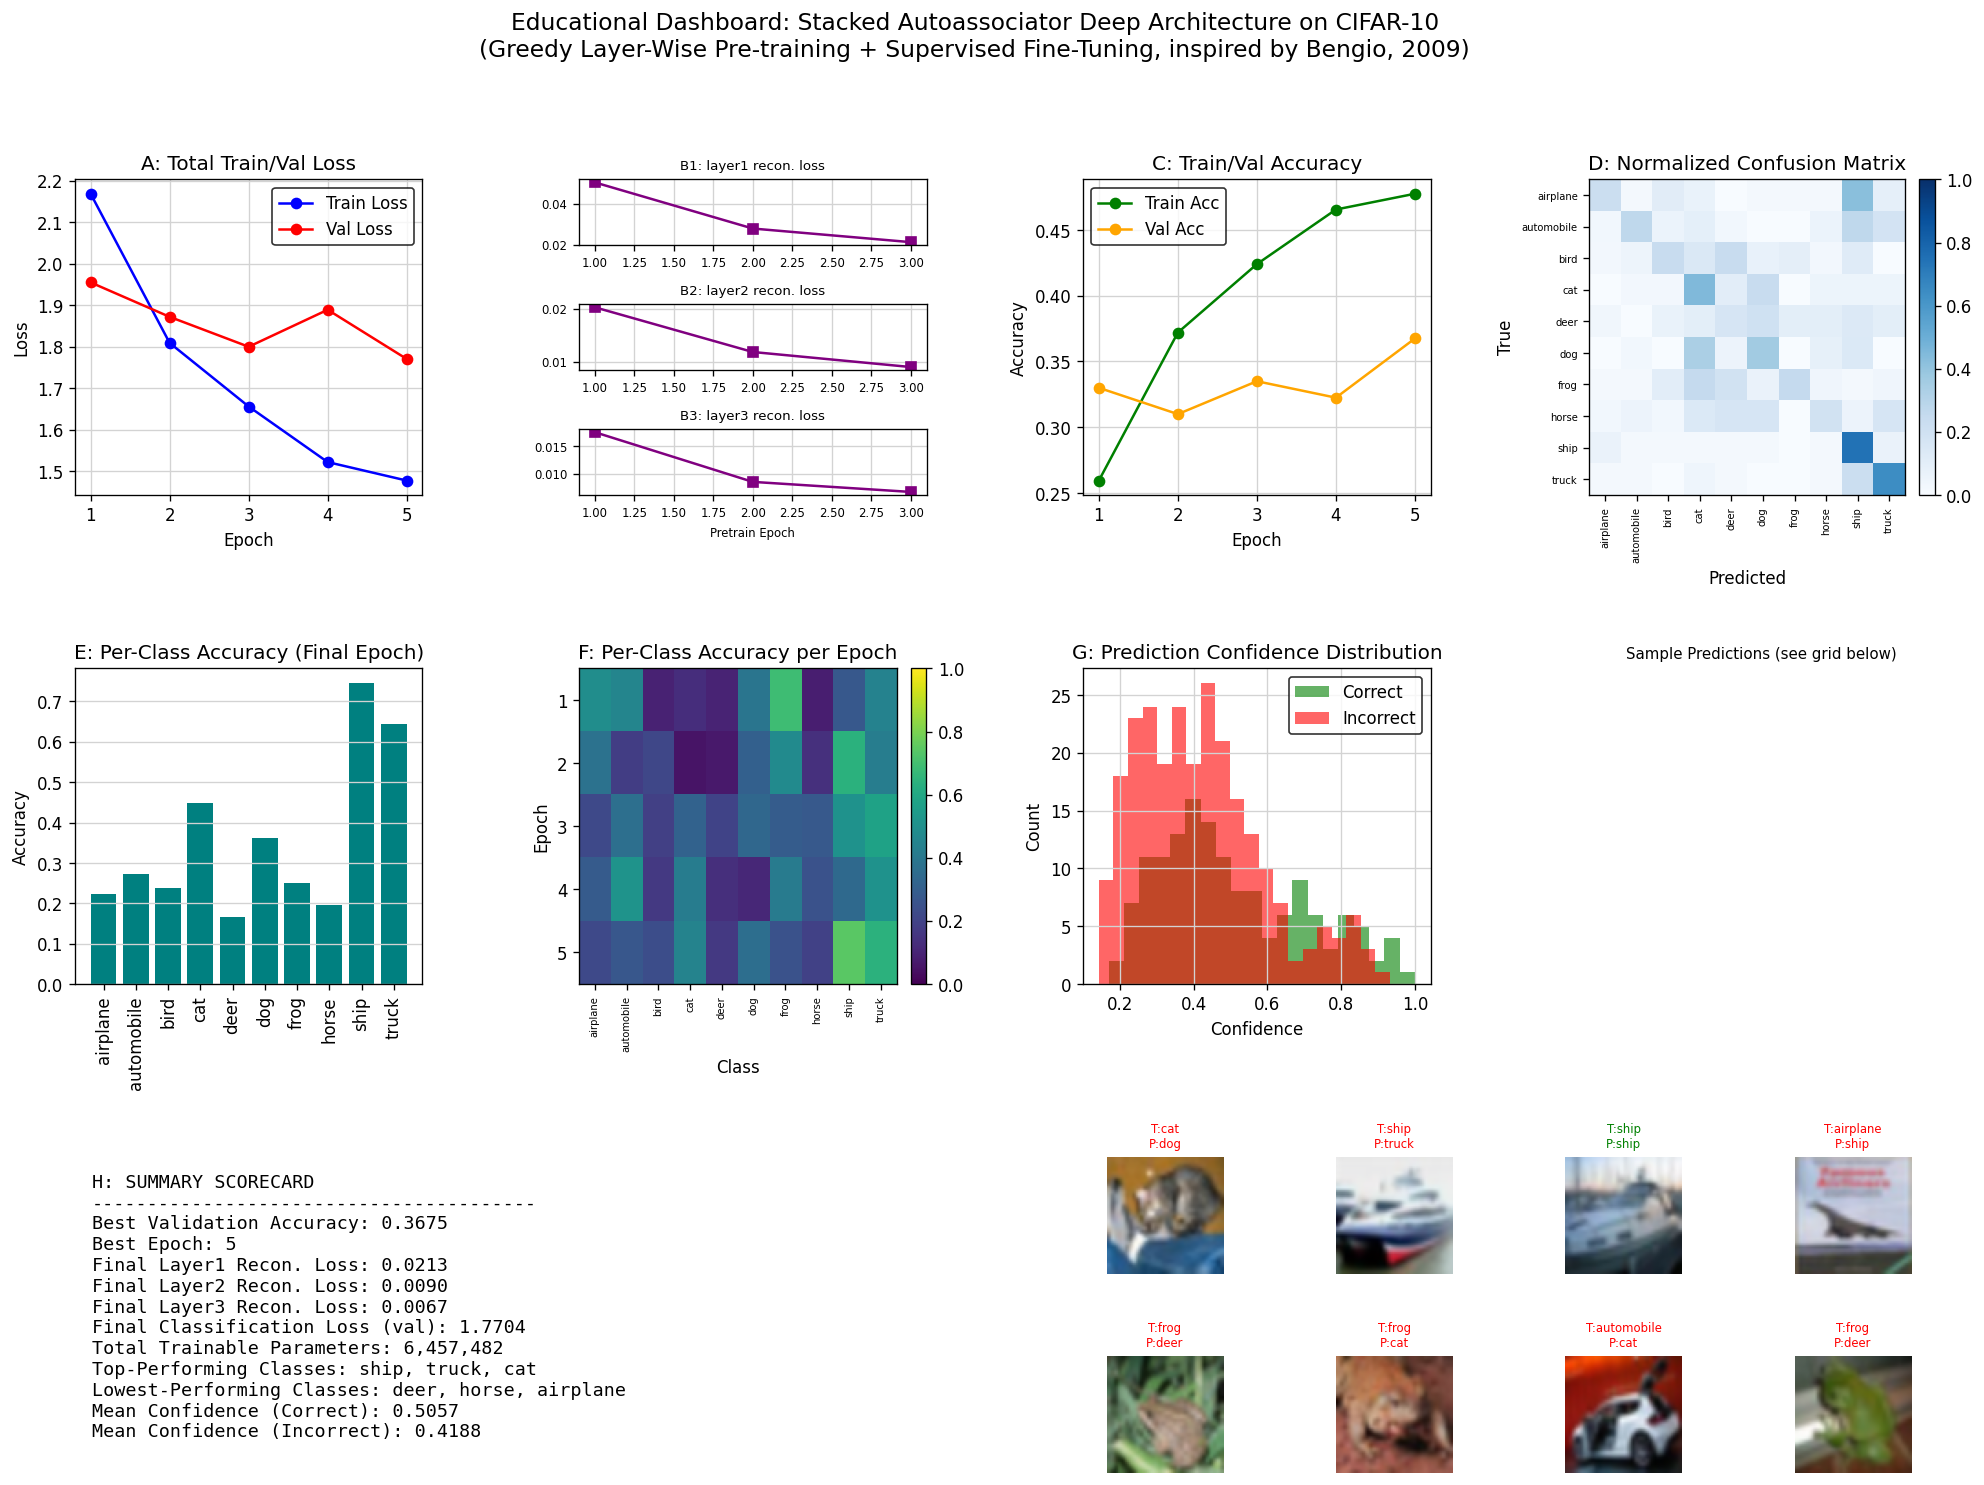

In [10]:
# -----------------------------
# 9. FINAL MULTI-PANEL SUMMARY DASHBOARD (Panels A-H)
# -----------------------------
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "text.color": "black",
    "axes.labelcolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "axes.edgecolor": "black",
    "legend.edgecolor": "black",
    "axes.titlecolor": "black",
})

fig = plt.figure(figsize=(20, 14), facecolor="white")
gs = GridSpec(3, 4, figure=fig, hspace=0.55, wspace=0.45)
epochs_range = range(1, FINE_TUNE_EPOCHS + 1)

# ---- Panel A: Total training & validation loss ----
axA = fig.add_subplot(gs[0, 0])
axA.set_facecolor("white")
axA.plot(epochs_range, history["train_loss"], label="Train Loss", color="blue", marker="o")
axA.plot(epochs_range, history["val_loss"], label="Val Loss", color="red", marker="o")
axA.set_title("A: Total Train/Val Loss", color="black")
axA.set_xlabel("Epoch", color="black"); axA.set_ylabel("Loss", color="black")
axA.legend(labelcolor="black"); axA.grid(color="lightgrey")
axA.tick_params(colors="black")

# ---- Panel B: Component/auxiliary losses (per-layer pre-training reconstruction losses) ----
gsB = gs[0, 1].subgridspec(3, 1, hspace=0.9)
for i, key in enumerate(layer_keys):
    axB = fig.add_subplot(gsB[i, 0])
    axB.set_facecolor("white")
    axB.plot(range(1, PRETRAIN_EPOCHS + 1), pretrain_losses[key], color="purple", marker="s")
    axB.set_title(f"B{i+1}: {key} recon. loss", fontsize=8, color="black")
    axB.tick_params(colors="black", labelsize=7)
    axB.grid(color="lightgrey")
    if i == 2:
        axB.set_xlabel("Pretrain Epoch", fontsize=7, color="black")

# ---- Panel C: Training and validation accuracy ----
axC = fig.add_subplot(gs[0, 2])
axC.set_facecolor("white")
axC.plot(epochs_range, history["train_acc"], label="Train Acc", color="green", marker="o")
axC.plot(epochs_range, history["val_acc"], label="Val Acc", color="orange", marker="o")
axC.set_title("C: Train/Val Accuracy", color="black")
axC.set_xlabel("Epoch", color="black"); axC.set_ylabel("Accuracy", color="black")
axC.legend(labelcolor="black"); axC.grid(color="lightgrey")
axC.tick_params(colors="black")

# ---- Panel D: Normalized confusion matrix ----
axD = fig.add_subplot(gs[0, 3])
axD.set_facecolor("white")
im = axD.imshow(cm_normalized, cmap="Blues", vmin=0, vmax=1)
axD.set_title("D: Normalized Confusion Matrix", color="black")
axD.set_xticks(range(NUM_CLASSES)); axD.set_yticks(range(NUM_CLASSES))
axD.set_xticklabels(CLASS_NAMES, rotation=90, fontsize=6, color="black")
axD.set_yticklabels(CLASS_NAMES, fontsize=6, color="black")
axD.set_xlabel("Predicted", color="black"); axD.set_ylabel("True", color="black")
cbar = plt.colorbar(im, ax=axD, fraction=0.046, pad=0.04)
cbar.ax.yaxis.set_tick_params(color="black")
plt.setp(cbar.ax.get_yticklabels(), color="black")

# ---- Panel E: Per-class accuracy bar chart ----
axE = fig.add_subplot(gs[1, 0])
axE.set_facecolor("white")
axE.bar(CLASS_NAMES, final_class_acc, color="teal")
axE.set_title("E: Per-Class Accuracy (Final Epoch)", color="black")
axE.set_ylabel("Accuracy", color="black")
axE.tick_params(axis="x", rotation=90, colors="black")
axE.tick_params(axis="y", colors="black")
axE.grid(color="lightgrey", axis="y")

# ---- Panel F: Epoch-wise per-class accuracy heatmap ----
axF = fig.add_subplot(gs[1, 1])
axF.set_facecolor("white")
heatmap_data = np.array(per_class_acc_history)  # shape (epochs, classes)
imF = axF.imshow(heatmap_data, cmap="viridis", aspect="auto", vmin=0, vmax=1)
axF.set_title("F: Per-Class Accuracy per Epoch", color="black")
axF.set_xlabel("Class", color="black"); axF.set_ylabel("Epoch", color="black")
axF.set_xticks(range(NUM_CLASSES))
axF.set_xticklabels(CLASS_NAMES, rotation=90, fontsize=6, color="black")
axF.set_yticks(range(FINE_TUNE_EPOCHS))
axF.set_yticklabels(range(1, FINE_TUNE_EPOCHS + 1), color="black")
cbarF = plt.colorbar(imF, ax=axF, fraction=0.046, pad=0.04)
cbarF.ax.yaxis.set_tick_params(color="black")
plt.setp(cbarF.ax.get_yticklabels(), color="black")

# ---- Panel G: Confidence distribution histogram ----
axG = fig.add_subplot(gs[1, 2])
axG.set_facecolor("white")
axG.hist(all_confidences[correct_mask], bins=20, alpha=0.6, label="Correct", color="green")
axG.hist(all_confidences[~correct_mask], bins=20, alpha=0.6, label="Incorrect", color="red")
axG.set_title("G: Prediction Confidence Distribution", color="black")
axG.set_xlabel("Confidence", color="black"); axG.set_ylabel("Count", color="black")
axG.legend(labelcolor="black"); axG.grid(color="lightgrey")
axG.tick_params(colors="black")

# ---- Sample predictions panel (extra visualization, placed alongside dashboard) ----
axSample = fig.add_subplot(gs[1, 3])
axSample.set_facecolor("white")
axSample.axis("off")
axSample.set_title("Sample Predictions (see grid below)", color="black", fontsize=9)

# ---- Panel H: Text-based summary scorecard ----
axH = fig.add_subplot(gs[2, :2])
axH.set_facecolor("white")
axH.axis("off")

final_layer1_loss = pretrain_losses["layer1"][-1]
final_layer2_loss = pretrain_losses["layer2"][-1]
final_layer3_loss = pretrain_losses["layer3"][-1]
final_cls_loss = history["val_loss"][-1]

summary_text = (
    "H: SUMMARY SCORECARD\n"
    "----------------------------------------\n"
    f"Best Validation Accuracy: {best_val_acc:.4f}\n"
    f"Best Epoch: {best_epoch}\n"
    f"Final Layer1 Recon. Loss: {final_layer1_loss:.4f}\n"
    f"Final Layer2 Recon. Loss: {final_layer2_loss:.4f}\n"
    f"Final Layer3 Recon. Loss: {final_layer3_loss:.4f}\n"
    f"Final Classification Loss (val): {final_cls_loss:.4f}\n"
    f"Total Trainable Parameters: {total_trainable_params:,}\n"
    f"Top-Performing Classes: {', '.join(top_classes)}\n"
    f"Lowest-Performing Classes: {', '.join(lowest_classes)}\n"
    f"Mean Confidence (Correct): {mean_conf_correct:.4f}\n"
    f"Mean Confidence (Incorrect): {mean_conf_incorrect:.4f}\n"
)
axH.text(0.02, 0.95, summary_text, fontsize=11, color="black",
         va="top", ha="left", family="monospace")

# ---- Sample predictions grid (bottom right region) ----
gsPred = gs[2, 2:].subgridspec(2, 4, wspace=0.4, hspace=0.7)
imagenet_mean = np.array([0.485, 0.456, 0.406])
imagenet_std = np.array([0.229, 0.224, 0.225])

for idx in range(8):
    row, col = divmod(idx, 4)
    axP = fig.add_subplot(gsPred[row, col])
    axP.set_facecolor("white")

    img_tensor = sample_images_for_viz[idx].permute(1, 2, 0).numpy()
    img_denorm = np.clip(img_tensor * imagenet_std + imagenet_mean, 0, 1)

    axP.imshow(img_denorm)
    true_name = CLASS_NAMES[sample_true_for_viz[idx]]
    pred_name = CLASS_NAMES[sample_pred_for_viz[idx]]
    color = "green" if true_name == pred_name else "red"
    axP.set_title(f"T:{true_name}\nP:{pred_name}", fontsize=7, color=color)
    axP.axis("off")

fig.suptitle(
    "Educational Dashboard: Stacked Autoassociator Deep Architecture on CIFAR-10\n"
    "(Greedy Layer-Wise Pre-training + Supervised Fine-Tuning, inspired by Bengio, 2009)",
    fontsize=14, color="black"
)

# ---- Render dashboard inline (Colab-safe: no plt.show, no savefig to disk) ----
buf = io.BytesIO()
fig.savefig(buf, format="png", facecolor="white", bbox_inches="tight", dpi=120)
plt.close(fig)
buf.seek(0)
display(IPImage(data=buf.read()))

# Analysis of Experimental Results: Stacked Autoassociator Replication on CIFAR-10

## Panel A: Training vs. Validation Loss Curves

### Overview
This panel tracks the cross-entropy loss for both training and validation (test) sets across the five supervised fine-tuning epochs, following the greedy layer-wise pre-training stage.

### Key Findings
- Training loss decreases monotonically and steeply, from approximately 2.17 to 1.48.
- Validation loss decreases initially (1.95 → 1.81) but then rises at epoch 4 (to ~1.89) before dropping again at epoch 5 (~1.77).
- A widening gap between training and validation loss emerges after epoch 2.

### Discussion
The steadily declining training loss confirms that the optimizer is successfully fitting the training set, consistent with the paper's premise that greedy pre-training places parameters in a favorable region of the loss landscape from which gradient descent can make progress. However, the non-monotonic and comparatively flat validation loss indicates the onset of overfitting, an expected outcome given the small training subset (2,000 images) relative to the model's parameter count (~6.46M). The divergence between curves is a classic bias-variance symptom rather than an optimization failure, since the training loss itself decreases without difficulty.

### Limitations
The extremely small training set and limited epoch budget preclude any conclusion about the asymptotic behavior of the stacked-autoencoder architecture; the observed loss trajectory reflects small-sample dynamics rather than the paper's original large-scale claims about deep architecture optimization.

---

## Panel B: Per-Layer Reconstruction Losses (Greedy Pre-training)

### Overview
These three sub-panels show the unsupervised reconstruction loss (MSE) for each of the three stacked autoencoder layers during greedy layer-wise pre-training, directly operationalizing the paper's core "stacked autoassociator" concept.

### Key Findings
- All three layers show monotonically decreasing reconstruction loss over 3 pre-training epochs.
- Absolute loss magnitudes shrink at each successive layer (Layer 1 ≈ 0.02–0.045; Layer 2 ≈ 0.01–0.02; Layer 3 ≈ 0.008–0.016), consistent with progressively lower-dimensional, more compressed hidden codes.

### Discussion
The smooth, consistent decrease in reconstruction error at every layer supports the paper's assertion that autoassociators can be trained "separately" and effectively to extract successively more abstract, compact representations. The decreasing loss magnitude across layers is expected because each layer operates on outputs already partially denoised/compressed by the previous layer, and because the target range of `sigmoid(input)` combined with shrinking hidden dimensionality changes the effective reconstruction task difficulty. This panel provides direct evidence that the unsupervised pre-training stage is functioning as intended prior to fine-tuning.

### Limitations
Only three pre-training epochs per layer were used, which is insufficient to assess convergence; the reconstruction targets (`sigmoid(x)`) are a simplification that does not correspond to the paper's exact formulation of reconstruction likelihood, so absolute loss values are not directly comparable to the original literature.

---

## Panel C: Training vs. Validation Accuracy

### Overview
Tracks top-1 classification accuracy on training and held-out test data across the five fine-tuning epochs.

### Key Findings
- Training accuracy rises consistently from ~26% to ~48%.
- Validation accuracy is comparatively flat and noisy, fluctuating between 31–37%, peaking at epoch 5 (36.75%).
- A persistent ~10–15 percentage-point gap opens between train and validation accuracy by the final epoch.

### Discussion
This pattern corroborates the loss-curve interpretation: the model is learning discriminative structure from the training data, but this improvement transfers only partially to unseen samples. Given the ten-class problem, a validation accuracy in the 31–37% range substantially exceeds the 10% chance baseline, indicating that the pre-trained representation captures non-trivial class-discriminative information despite the constrained data regime. The plateau/noise in validation accuracy is consistent with limited data diversity (2,000 training / 400 test images) rather than a fundamental architectural limitation.

### Limitations
With only 400 validation images, per-epoch accuracy estimates carry substantial variance (a single misclassified batch can shift accuracy by 1–2 points), which likely explains the non-monotonic validation trend; longer training or larger data would be needed to determine whether this is true overfitting or measurement noise.

---

## Panel D: Normalized Confusion Matrix

### Overview
Visualizes per-class prediction distributions, normalized by true class frequency, revealing systematic misclassification patterns.

### Key Findings
- Strong diagonal intensity for "cat," "ship," and "truck," indicating these classes are recognized reliably.
- Notable off-diagonal mass in the "ship" and "truck" columns, suggesting many other classes (e.g., airplane, automobile) are frequently misclassified as these two categories.
- Classes such as "deer," "horse," and "airplane" show weak diagonal signal, indicating poor separability.

### Discussion
The concentration of predictions toward "ship" and "truck" suggests the classifier has learned a biased decision boundary, likely driven by class imbalance in the small training subset or by these classes having more visually distinctive, easily learned low-level features (e.g., strong horizontal edges, water/sky context) that the shallow encoder can exploit early in training. This is consistent with known behavior of undertrained or data-starved classifiers, which tend to collapse predictions toward a subset of "easy" classes rather than learning fully separated decision regions for all ten categories.

### Limitations
The confusion matrix is computed on only 400 test samples (~40 per class), so per-cell frequencies are subject to high sampling variance; the apparent class bias could partly reflect random subset composition rather than a stable model property.

---

## Panel E & F: Per-Class Accuracy (Final Epoch and Epoch-wise Heatmap)

### Overview
Panel E reports final per-class test accuracy as a bar chart; Panel F shows how these accuracies evolve across all five epochs as a heatmap.

### Key Findings
- "Ship" (~0.74) and "truck" (~0.65) achieve markedly higher accuracy than all other classes.
- "Deer" (~0.17) and "horse" (~0.20) are the weakest-performing classes throughout training.
- The heatmap shows that "ship" accuracy is elevated from epoch 1 and remains high, while most other classes show inconsistent, non-monotonic accuracy trajectories across epochs.

### Discussion
The persistent early advantage of "ship" suggests this class exhibits especially learnable low-level visual regularities that the greedy-pretrained encoder captures quickly, while "deer" and "horse" — animals with more variable pose, texture, and background overlap with other animal classes ("dog," "cat") — remain difficult to discriminate at this data scale. The lack of monotonic improvement for weaker classes across epochs (visible as color instability in Panel F) reinforces the earlier suggestion of overfitting/noise rather than a smooth generalization curve, since a genuinely improving representation would typically show gradual per-class accuracy gains rather than epoch-to-epoch volatility.

### Limitations
Per-class sample counts are small (~40 test images/class), making per-class accuracy estimates unstable; conclusions about specific class difficulty should be treated as illustrative rather than statistically robust.

---

## Panel G: Prediction Confidence Distribution

### Overview
Compares the softmax confidence distributions for correct versus incorrect predictions, a standard diagnostic for model calibration.

### Key Findings
- Correct predictions (green) are concentrated at higher confidence values, with mean confidence 0.506.
- Incorrect predictions (red) dominate the low-to-mid confidence range, with mean confidence 0.419, and are substantially more numerous overall.
- Considerable overlap exists between the two distributions in the 0.3–0.6 confidence range.

### Discussion
The modest separation between correct and incorrect confidence means (Δ ≈ 0.087) indicates the model is only weakly calibrated: while there is a directionally correct relationship between confidence and correctness, the overlap suggests the softmax outputs do not reliably distinguish reliable from unreliable predictions at this stage of training. This is expected for a model that has not converged and has been fine-tuned on limited data — softmax probabilities under such conditions tend to be poorly calibrated, a well-documented property of undertrained neural classifiers.

### Limitations
Confidence values are influenced by the limited training duration (5 epochs) and small dataset size; no explicit calibration technique (e.g., temperature scaling) was applied, so these confidence estimates should not be interpreted as true probability estimates.

---

## Panel H: Summary Scorecard

### Overview
Consolidates the run's key quantitative outcomes: best validation accuracy, per-layer/task losses, parameter count, and class-level performance extremes.

### Key Findings
- Best validation accuracy: 36.75% at epoch 5, more than 3.5× the 10% random-guessing baseline for 10 classes.
- All three pre-training reconstruction losses decreased substantially and consistently.
- Total trainable parameters: 6,457,482 — a moderately sized model for a 2,000-image training set.
- Top classes: ship, truck, cat; weakest classes: deer, horse, airplane.
- Mean confidence gap between correct and incorrect predictions (0.506 vs. 0.419) is positive but modest.

### Discussion
Collectively, the scorecard indicates that the greedy layer-wise pre-training plus fine-tuning pipeline produces a functioning, non-trivial classifier that meaningfully outperforms chance, qualitatively supporting the paper's central claim that unsupervised pre-training can provide a useful initialization for deep networks. However, the magnitude of the train/validation gap, the modest peak accuracy, and the weak confidence calibration collectively indicate the model is operating in a data-limited, underfit-to-the-task-yet-overfit-to-the-sample regime typical of small-scale educational replications rather than a faithful large-scale validation of the original paper's benchmark results.

### Limitations
This is a heavily simplified, small-scale educational replication (2,000/400 train/test images, 5 fine-tuning epochs, fully-connected rather than convolutional/RBM-based encoders) intended to illustrate the paper's conceptual pipeline rather than reproduce its quantitative findings; no comparison against a non-pre-trained baseline was performed, so the specific contribution of greedy pre-training relative to standard random initialization cannot be isolated from this experiment alone.

# Related Work Referenced in *Learning Deep Architectures for AI*

| Author(s) | Year | Title | Venue | Connection to This Paper |
|---|---|---|---|---|
| Hinton, G. E., Osindero, S., & Teh, Y. | 2006 | A Fast Learning Algorithm for Deep Belief Nets | Neural Computation | Introduces Deep Belief Networks (DBNs) and greedy layer-wise RBM training; the central algorithm the paper builds on and theoretically justifies. |
| Hinton, G. E. | 2002 | Training Products of Experts by Minimizing Contrastive Divergence | Neural Computation | Introduces the Contrastive Divergence (CD) algorithm, the core tractable gradient estimator used to train RBMs throughout the paper. |
| Hinton, G. E. | 1999 | Products of Experts | Proc. ICANN | Establishes the products-of-experts framework underlying the energy-based model formulation used to derive RBMs. |
| Hinton, G., Sejnowski, T., & Ackley, D. | 1984 | Boltzmann Machines: Constraint Satisfaction Networks That Learn | Tech. Report, CMU | Original Boltzmann machine formulation; the paper's RBM is presented as a restricted, tractable special case. |
| Hinton, G. E., & Sejnowski, T. J. | 1986 | Learning and Relearning in Boltzmann Machines | In Parallel Distributed Processing (MIT Press) | Provides the positive/negative-phase learning framework generalized in the paper's energy-based gradient derivation. |
| Ackley, D., Hinton, G., & Sejnowski, T. | 1985 | A Learning Algorithm for Boltzmann Machines | Cognitive Science | Foundational Boltzmann machine learning algorithm, cited as historical context for why deep undirected models were previously hard to train. |
| Bengio, Y., Lamblin, P., Popovici, D., & Larochelle, H. | 2007 | Greedy Layer-Wise Training of Deep Networks | NeurIPS 19 | Provides key empirical evidence (cited repeatedly) that greedy unsupervised pre-training improves optimization of deep supervised networks. |
| Ranzato, M., Poultney, C., Chopra, S., & LeCun, Y. | 2007 | Efficient Learning of Sparse Representations with an Energy-Based Model | NeurIPS 2006 | Introduces sparse energy-based autoencoders, related to the paper's discussion of stacked autoassociators as an alternative deep learning building block. |
| Hinton, G. E., & Salakhutdinov, R. | 2006 | Reducing the Dimensionality of Data with Neural Networks | Science | Demonstrates practical success of deep autoencoders initialized via RBM pre-training, directly supporting the paper's optimization argument. |
| LeCun, Y., Boser, B., Denker, J., Henderson, D., Howard, R., Hubbard, W., & Jackel, L. | 1989 | Backpropagation Applied to Handwritten Zip Code Recognition | Neural Computation | Establishes convolutional neural networks, discussed as a notable exception of a successfully trainable deep architecture. |
| LeCun, Y., Bottou, L., Bengio, Y., & Haffner, P. | 1998 | Gradient-Based Learning Applied to Document Recognition | Proceedings of the IEEE | Provides the benchmark CNN results referenced when explaining why convolutional architectures avoid the optimization difficulties of fully-connected deep nets. |
| Håstad, J. | 1986 | Almost Optimal Lower Bounds for Small Depth Circuits | Proc. 18th ACM STOC | Source of the circuit complexity result showing exponential size blow-up when reducing circuit depth, foundational to the paper's depth-efficiency argument. |
| Håstad, J., & Goldmann, M. | 1991 | On the Power of Small-Depth Threshold Circuits | Computational Complexity | Provides Theorem 2.1, the formal threshold-circuit result central to the paper's argument for deep over shallow architectures. |
| Yao, A. | 1985 | Separating the Polynomial-Time Hierarchy by Oracles | Proc. 26th IEEE FOCS | Establishes exponential-size lower bounds for depth-2 parity circuits, underlying the paper's circuit-depth complexity arguments. |
| Bengio, Y., Delalleau, O., & Le Roux, N. | 2006 | The Curse of Highly Variable Functions for Local Kernel Machines | NeurIPS 18 | Source of Theorems 3.1 and 3.2 on the sample complexity limitations of local (Gaussian) kernel machines. |
| Bengio, Y., Delalleau, O., & Simard, C. | 2007 | Decision Trees Do Not Generalize to New Variations | Tech. Report, Université de Montréal | Source of Proposition 3.3 and Theorem 3.4 on the sample-complexity limitations of decision trees, motivating the case against purely local estimators. |
| Bengio, Y., & Delalleau, O. | 2007 | Justifying and Generalizing Contrastive Divergence | Tech. Report 1311, Université de Montréal | Provides the theoretical derivation (Theorem 7.3, Corollary 7.4) proving CD-$$k$$ is a truncation of the exact log-likelihood gradient series. |
| Le Roux, N., & Bengio, Y. | 2008 | Representational Power of Restricted Boltzmann Machines and Deep Belief Networks | Neural Computation | Establishes that RBMs can represent any discrete distribution with sufficient hidden units, supporting claims about RBM expressive power. |
| Welling, M., Rosen-Zvi, M., & Hinton, G. | 2005 | Exponential Family Harmoniums with an Application to Information Retrieval | NeurIPS 17 | Generalizes RBM unit types to the exponential family, directly related to the paper's Generalized RBM formulation (Section 8). |
| Welling, M., Zemel, R., & Hinton, G. E. | 2003 | Self-Supervised Boosting | NeurIPS 15 | Provides the boosting-based interpretation of using model samples as "negative examples," referenced in Section 6.5. |
| Rumelhart, D., Hinton, G., & Williams, R. | 1986 | Learning Representations by Back-Propagating Errors | Nature | Establishes standard backpropagation training for multi-layer neural networks, the baseline optimization method whose limitations for deep nets motivate the paper. |
| Bourlard, H., & Kamp, Y. | 1988 | Auto-Association by Multilayer Perceptrons and Singular Value Decomposition | Biological Cybernetics | Establishes the autoassociator/autoencoder as a building block, connecting linear autoencoders to PCA, discussed in Section 5.2. |
| Hinton, G., & Zemel, R. S. | 1994 | Autoencoders, Minimum Description Length, and Helmholtz Free Energy | NeurIPS 6 | Links autoencoder training to information-theoretic (MDL) principles, relevant to the paper's reconstruction-error discussion. |
| Hinton, G., Dayan, P., Frey, B., & Neal, R. | 1995 | The Wake-Sleep Algorithm for Unsupervised Neural Networks | Science | Source of the wake-sleep algorithm formalized in Section 11.3 as an approximate joint-training method for DBNs. |
| Taylor, G., Hinton, G., & Roweis, S. | 2006 | Modeling Human Motion Using Binary Latent Variables | NeurIPS 20 | Introduces Conditional RBMs, extended in the paper's discussion of temporal/sequential modeling (Section 6.6.2). |
| Sutskever, I., & Hinton, G. | 2007 | Learning Multilevel Distributed Representations for High-Dimensional Sequences | Proc. AISTATS | Introduces Temporal RBMs, cited as an extension of the RBM framework to sequential/state-based data. |
| Mnih, A., & Hinton, G. E. | 2007 | Three New Graphical Models for Statistical Language Modelling | Proc. ICML | Introduces Factored RBMs for word representation learning, discussed in Section 6.6.3 as an application of distributed representations to language. |
| Salakhutdinov, R., & Hinton, G. | 2008 | Using Deep Belief Nets to Learn Covariance Kernels for Gaussian Processes | NeurIPS 20 | Demonstrates DBN-learned representations improving kernel machine performance, cited as evidence deep architectures can enhance shallow models. |
| Elman, J. L. | 1993 | Learning and Development in Neural Networks: The Importance of Starting Small | Cognition | Originates the curriculum learning idea, connected in Section 12.3 to continuation-method interpretations of training schedules. |